/content
Cloning into 'rainfall_kf'...
remote: Enumerating objects: 370, done.
remote: Counting objects: 100% (225/225), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 370 (delta 128), reused 136 (delta 62), pack-reused 145 (from 1)
Receiving objects: 100% (370/370), 111.08 MiB | 26.66 MiB/s, done.
Resolving deltas: 100% (164/164), done.
/content/rainfall_kf
Obtaining file:///content/rainfall_kf
  Preparing metadata (setup.py) ... done
  Running setup.py develop for rainfall_kf
/content
Cloning into 'rainfall_kf'...
remote: Enumerating objects: 370, done.
remote: Counting objects: 100% (225/225), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 370 (delta 128), reused 136 (delta 62), pack-reused 145 (from 1)
Receiving objects: 100% (370/370), 111.08 MiB | 25.72 MiB/s, done.
Resolving deltas: 100% (164/164), done.
/content/rainfall_kf
Obtaining file:///content/rainfall_kf
  Preparing metadata (setup.py) ... done
  Running setup.py develop fo

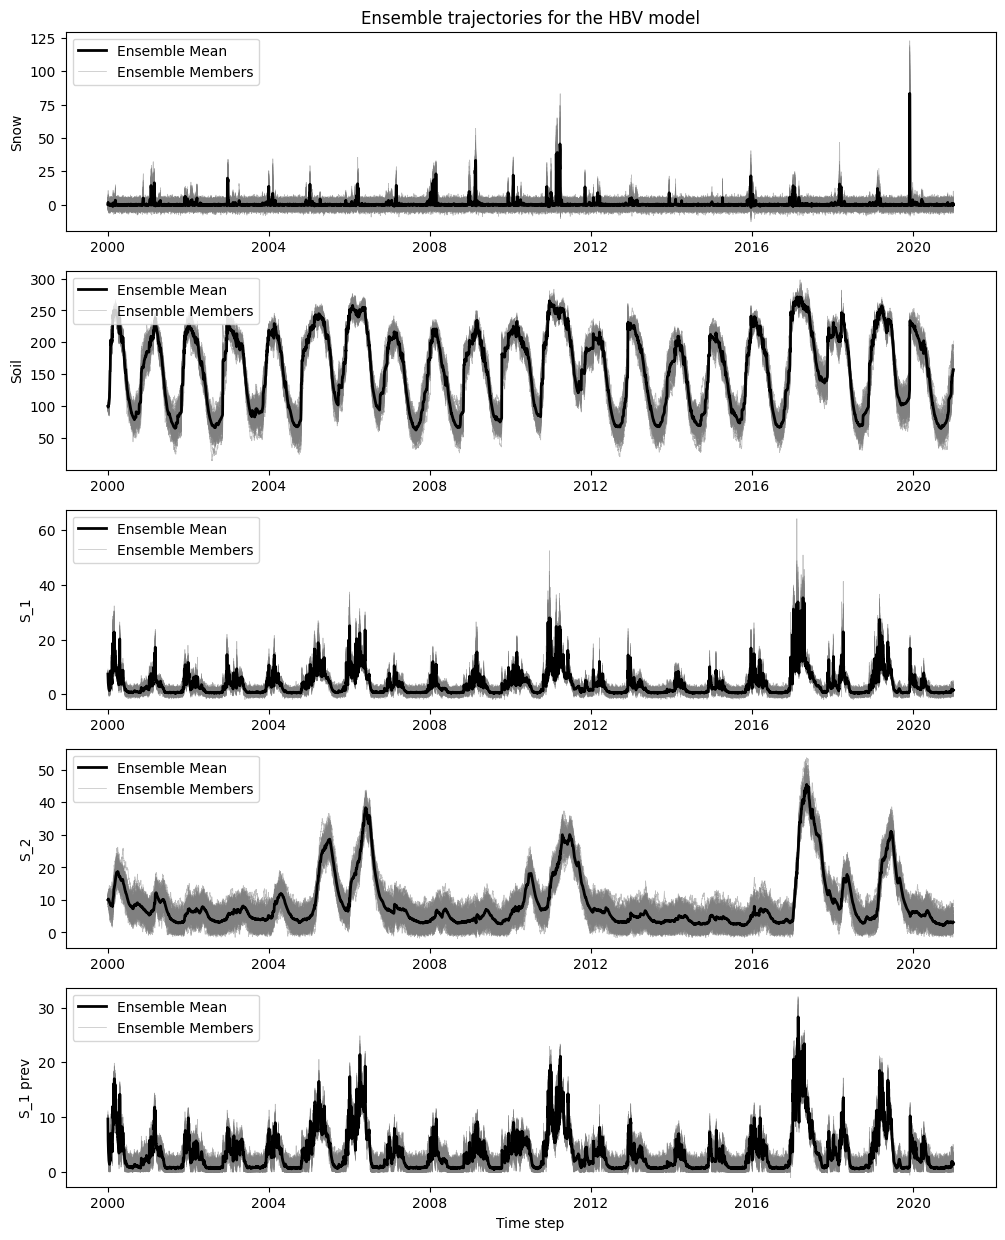

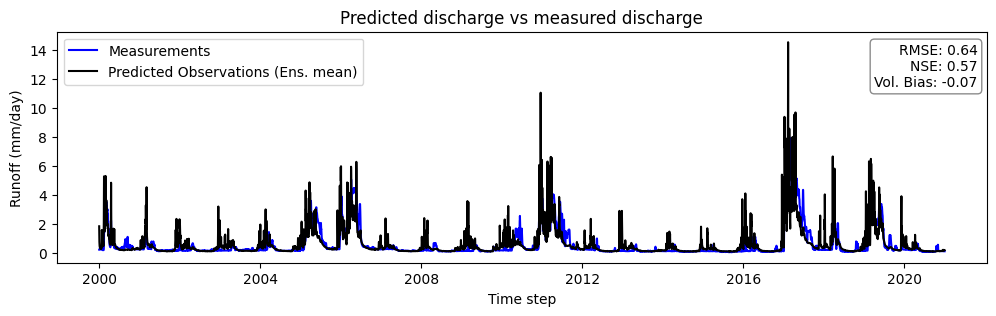

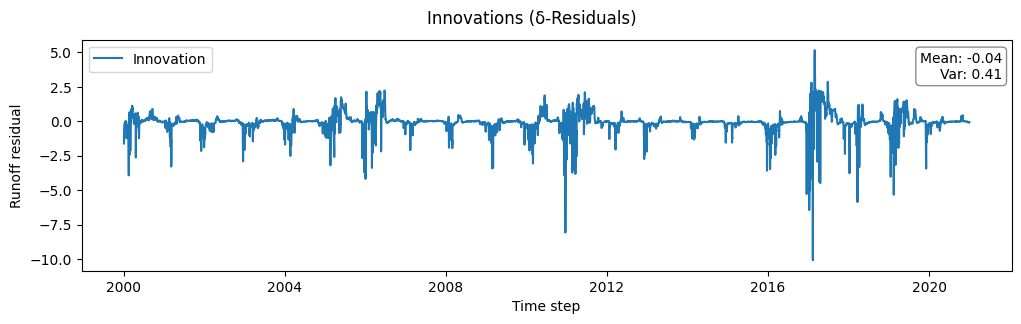

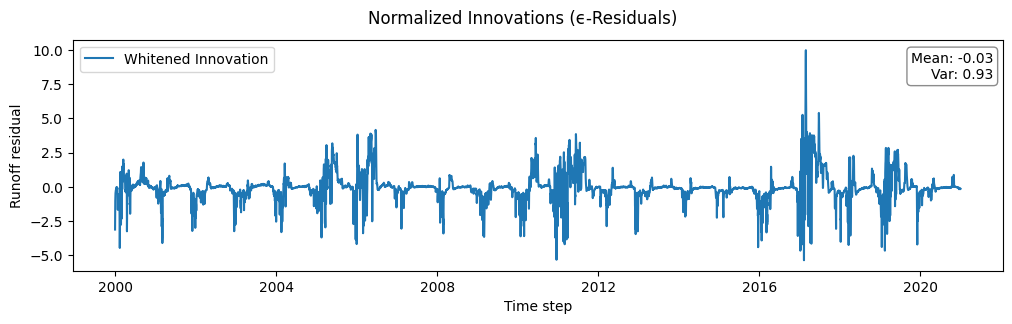

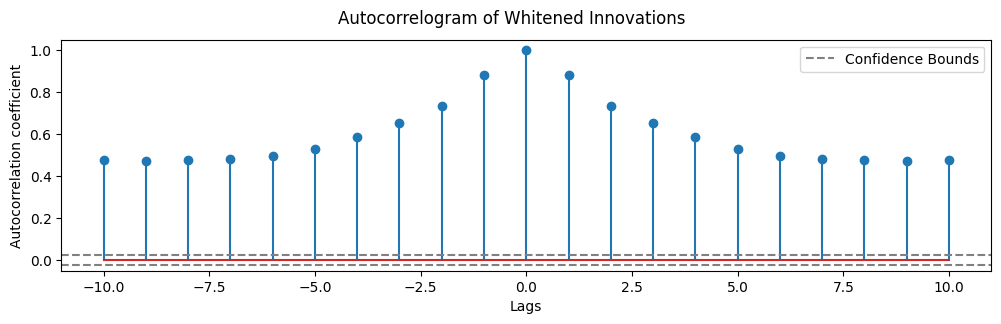

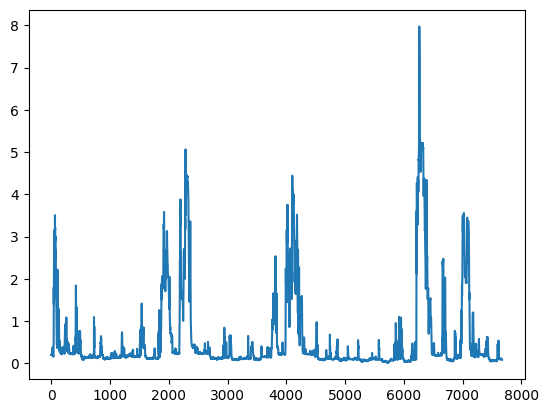

In [1]:
!pip install -q spotpy

import numpy as np
import spotpy
import matplotlib.pyplot as plt

%cd /content
!rm -rf rainfall_kf
!git clone https://github.com/Felix-Schwer/rainfall_kf.git
%cd rainfall_kf
!pip install -e .
!wget -q https://raw.githubusercontent.com/Felix-Schwer/rainfall_kf/main/notebooks/Run_HBVEDU_SJV_Colab.ipynb
%run Run_HBVEDU_SJV_Colab.ipynb

# import HBV
from rainfall_kf.models.hbvedu import HBVParameters, HBVObservation, HBVTransition


def peak_flow_error(obs, sim, percentile=90):
    # only storm events, I put an example number, we could change the percentile
    threshold = np.percentile(obs, percentile)
    mask = obs >= threshold
    if np.sum(mask) == 0: return 0.0
    return np.mean(np.abs(obs[mask] - sim[mask]))


def weighted_rmse(obs, sim):
    # higher penalty on large flows
    threshold = np.percentile(obs, 90)
    weights = np.where(obs >= threshold, 3.0, 1.0)
    return np.sqrt(np.mean(weights * (obs - sim)**2))


In [4]:
class Direct_SJV_Calibration:
    def __init__(self, observed_flow, inputs_k, initial_state):
        # ranges are from the 2000 Seibert paper, could change it based on our data, we can calibrate other parameters as needed
        # maybe we can just use ALPHA to make things easier?
        self.params = [
            spotpy.parameter.Uniform('d', low=1.0, high=10.0),
            spotpy.parameter.Uniform('fc', low=50, high=500),
            spotpy.parameter.Uniform('k0', low=0.1, high=0.5),
            spotpy.parameter.Uniform('k1', low=0.05, high=0.3),
            spotpy.parameter.Uniform('k2', low=0.001, high=0.1),
            spotpy.parameter.Uniform('tt', low=-1.5, high=2.5),
        ]

        self.observations = observed_flow
        self.inputs_k = inputs_k
        self.x0 = initial_state
        self.k_steps = inputs_k.shape[1]

    def parameters(self):
        return spotpy.parameter.generate(self.params)

    def simulation(self, vector):
        # Unpack the guessed parameters
        d_guess, fc_guess, k0_guess, k1_guess, k2_guess, tt_guess = vector

        test_params = HBVParameters(
            d=d_guess,
            fc=fc_guess,
            beta=4.0775,
            c=0.0316,
            k0=k0_guess,
            l=4.825,
            k1=k1_guess,
            k2=k2_guess,
            kp=0.0367,
            pwp=164.45,
            tt=tt_guess
        )



        x = self.x0.copy()
        simulated_q = np.zeros(self.k_steps)

        for k in range(self.k_steps):

            u_k = self.inputs_k[:, k:k+1]

            x = HBVTransition(x, u_k, test_params)

            simulated_q[k] = HBVObservation(x, test_params).item()

        return simulated_q

    def evaluation(self):
        return self.observations[0, :]

    def objectivefunction(self, simulation, evaluation):
        valid_idx = ~np.isnan(evaluation)
        sim_valid = simulation[valid_idx]
        eval_valid = evaluation[valid_idx]


        if len(sim_valid) == 0: return 999999.0

        # Calculate Mmtrics
        nse = spotpy.objectivefunctions.nashsutcliffe(eval_valid, sim_valid)


        sim_valid_log = np.where(sim_valid <= 0, 1e-6, sim_valid)
        eval_valid_log = np.where(eval_valid <= 0, 1e-6, eval_valid)

        log_nse = spotpy.objectivefunctions.nashsutcliffe(np.log(eval_valid_log), np.log(sim_valid_log))
        pbias = spotpy.objectivefunctions.pbias(eval_valid, sim_valid)


        peak_err = peak_flow_error(eval_valid, sim_valid)
        w_rmse = weighted_rmse(eval_valid, sim_valid)

        max_q = np.max(eval_valid) if np.max(eval_valid) > 0 else 1.0
        peak_norm = peak_err / max_q
        w_rmse_norm = w_rmse / max_q


        # Seibert multi-criteria cost function
        cost = (
            0.30 * (1 - nse) +
            0.25 * (1 - log_nse) +
            0.10 * (abs(pbias) / 100) +
            0.15 * peak_norm +
            0.20 * w_rmse_norm
        )

        # minimize cost
        return cost

Initializing the  Shuffled Complex Evolution (SCE-UA) algorithm  with  100  repetitions
The objective function will be minimized
Starting burn-in sampling...
Initialize database...
['csv', 'hdf5', 'ram', 'sql', 'custom', 'noData']
* Database file 'SJV_Direct_Calibration.csv' created.
3 of 100, minimal objective function=2.87705, time remaining: 00:00:55
5 of 100, minimal objective function=2.87705, time remaining: 00:01:15
8 of 100, minimal objective function=2.87705, time remaining: 00:01:09
11 of 100, minimal objective function=1.99571, time remaining: 00:01:05
14 of 100, minimal objective function=1.99571, time remaining: 00:01:02
17 of 100, minimal objective function=1.99571, time remaining: 00:00:59
20 of 100, minimal objective function=1.99571, time remaining: 00:00:57
22 of 100, minimal objective function=1.61408, time remaining: 00:00:59
25 of 100, minimal objective function=1.61408, time remaining: 00:00:56
28 of 100, minimal objective function=1.61408, time remaining: 00:00:5

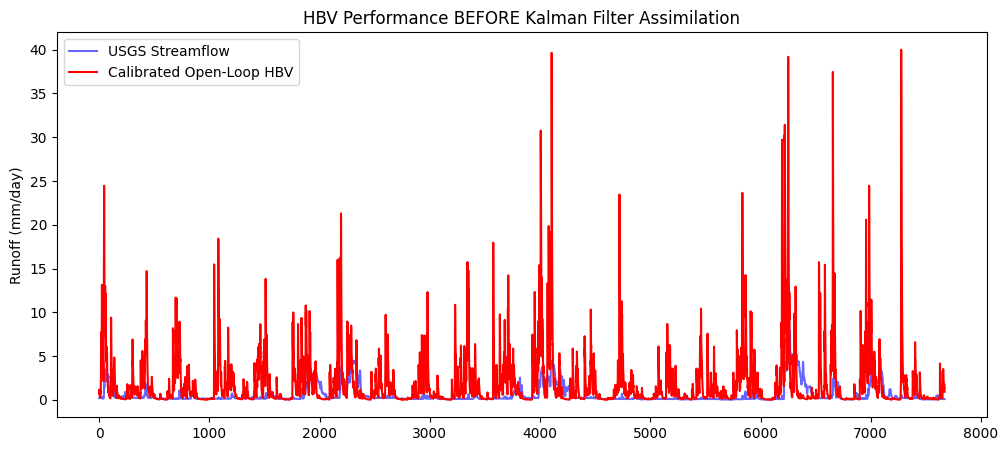

In [5]:
calibration_setup = Direct_SJV_Calibration(
    observed_flow=observations,
    inputs_k=inputs,
    # initial value, I put random numbers here
    initial_state=np.array([[0., 100., 10., 10., 10.]]).T
)

# find the best parameters
sampler = spotpy.algorithms.sceua(calibration_setup, dbname='SJV_Direct_Calibration', dbformat='csv')
sampler.sample(100)

# get best parameters
results = spotpy.analyser.load_csv_results('SJV_Direct_Calibration')

best_index = np.argmin(results['like1'])
print(f"Best Multi-Criteria Score: {results['like1'][best_index]:.3f}")

# final parameters
final_calibrated_params = HBVParameters(
    d=results['pard'][best_index],
    fc=results['parfc'][best_index],
    beta=4.0775,
    c=0.0316,
    k0=results['park0'][best_index],
    l=4.825,
    k1=results['park1'][best_index],
    k2=results['park2'][best_index],
    kp=0.0367,
    pwp=164.45,
    tt=results['partt'][best_index]
)

print(f"\nFinal Parameters:\n{final_calibrated_params}")

# Plot the best run
best_sim = calibration_setup.simulation([
    results['parfc'][best_index],
    results['park0'][best_index],
    results['park1'][best_index],
    results['park2'][best_index],
    results['partt'][best_index],
    results['pard'][best_index]
])

plt.figure(figsize=(12, 5))
plt.plot(observations[0, :], color='blue', alpha=0.6, label='USGS Streamflow')
plt.plot(best_sim, color='red', linewidth=1.5, label='Calibrated Open-Loop HBV')
plt.title('HBV Performance BEFORE Kalman Filter Assimilation')
plt.ylabel('Runoff (mm/day)')
plt.legend()
plt.show()